### **Tipos de Aprendizagem de Máquina:**

*   Supervisionada
*   Não-Supervisionada
*   Por Reforço



#### **Aprendizagem Supervisionada**

Na aprendizagem supervisionada, o algoritmo aprende a partir de um conjunto de dados com saídas definidas. Isso significa que cada registro de entrada tem uma saída correspondente. Os dados ( X ) são chamados de Previsores, enquanto a saída ( Y ) é chamada de Classificador. Exemplos:

*   Previsão do preço de uma casa com base em suas características (Regressão).
*   Classificação de e-mails como spam ou não spam (Classificação).
*   Reconhecimento de imagens para identificar objetos (Classificação).

#### **Aprendizagem Não-Supervisionada**

Na aprendizagem não supervisionada, o algoritmo aprende a partir de dados não rotulados, ou seja, que não possuem uma saída definida. O objetivo é encontrar padrões ocultos, estruturas ou relacionamentos nos dados sem qualquer orientação. Exemplos:

*   Agrupamento de clientes com base em seu padrão de compra (Clustering).
*   Redução da dimensionalidade de um conjunto de dados.
*   Detecção de anomalias ou outliers nos dados.

#### **Aprendizagem por Reforço**

Na aprendizagem por reforço, um agente aprende a tomar decisões em um ambiente para maximizar uma recompensa acumulada. O agente aprende através da tentativa e erro, recebendo feedback na forma de recompensas ou penalidades por suas ações. Exemplos:

*   Treinamento de um robô para andar.
*   Desenvolvimento de agentes para jogar jogos (xadrez, Go, videogames).
*   Controle de sistemas autônomos (carros autônomos).

#### **Regressão Linear**

A Regressão Linear é utilizada para prever um **valor contínuo** com base em uma ou mais variáveis de entrada (features). O objetivo é encontrar a melhor linha (ou hiperplano) que descreva a relação entre as variáveis de entrada e a variável de saída.

#### **Regressão Linear Simples (Com um único Hiperplano)**

$y = \beta_0 + \beta_1 x + \epsilon$

Onde:
*   $y$ é a variável dependente (o que queremos prever).
*   $x$ é a variável independente (a feature).
*   $\beta_0$ é o intercepto (o valor de $y$ quando $x$ é 0).
*   $\beta_1$ é o coeficiente angular (a inclinação da linha, indicando o quanto $y$ muda quando $x$ muda em uma unidade).
*   $\epsilon$ é o erro aleatório (o ruído nos dados).

####**Regressão Linear múltipla (Multiplos Hiperplanos)**

$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n + \epsilon$

Onde $x_1, x_2, ..., x_n$ são as diferentes features e $\beta_1, \beta_2, ..., \beta_n$ são seus respectivos coeficientes.

O algoritmo de Regressão Linear aprende os valores de $\beta_0$ e $\beta_1$ (ou $\beta_0, \beta_1, ..., \beta_n$) que minimizam a soma dos quadrados dos erros entre os valores previstos e os valores reais.

In [33]:
#Import Libs
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_blobs

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
#Generate a Synthetic Dataset ( Dataframe ) to Apply Linear Regression
np.random.seed(0)
X = np.linspace(0, 10, 100)
np.random.shuffle(X)

In [4]:
#Show the Dataset
print(X)

[ 2.62626263  8.68686869  0.2020202   5.55555556  7.57575758  9.39393939
  1.61616162  7.37373737  5.45454545  9.5959596   5.35353535  9.29292929
  7.87878788  1.31313131  0.70707071  3.03030303  2.22222222  2.42424242
  3.33333333  0.80808081  4.34343434  6.26262626  0.3030303   7.17171717
  4.54545455  4.84848485  0.60606061 10.          8.28282828  7.67676768
  6.06060606  8.08080808  9.09090909  6.86868687  5.15151515  2.72727273
  1.81818182  5.65656566  6.36363636  7.47474747  0.1010101   6.16161616
  4.24242424  4.14141414  0.4040404   1.51515152  1.71717172  4.04040404
  3.83838384  0.50505051  9.19191919  5.95959596  0.          3.43434343
  2.82828283  5.05050505  1.11111111  3.53535354  2.32323232  5.25252525
  1.01010101  3.13131313  6.66666667  5.75757576  7.97979798  8.58585859
  3.23232323  8.48484848  1.41414141  8.98989899  1.91919192  2.92929293
  4.94949495  9.7979798   9.8989899   6.96969697  2.02020202  9.49494949
  7.27272727  7.77777778  2.52525253  3.73737374  8

In [5]:
#Create the Classifiers ( Y ) with Noise
noise = np.random.randn(100) * 2
y = 2 * X + 1 + noise

In [6]:
#Show the Results
print(y)

[ 7.10331205 18.31779501  4.35602007 13.40467131 15.42284653 18.43032401
  3.52506752 14.26597981 10.55904725 19.92635068 12.94667283 23.16819551
 17.09957663  0.17491992  2.73545849  5.34263542  5.03160256  6.82533778
  5.99000474  3.37848911  7.70506212 15.56101262  2.2892354  12.84166191
 11.94141059  8.88739738  5.89950427 24.05101448 14.6745854  17.10785658
 12.98009766 18.36993558 20.12611618 16.37720832 13.11806954  5.28289971
  6.51148132 11.80391513 15.67447015 16.36406049  3.40130415 15.20302628
 10.69762649  9.28634996 -0.17223948  7.77509119  3.95219625  9.18749789
 10.73839957 -0.54387696 21.05927791  9.93896909 -1.14043001  7.45042963
  7.86571021  7.61489364  6.27067585 11.79785771  8.22922049 14.10644305
  4.85660767  6.94502532 12.40520662  8.53359388 17.13905741 18.40142493
  6.2930161  18.56724105  4.27280263 19.85016391  4.74688764  6.95838269
  9.02792899 21.1707349  21.51883433 15.75569018  1.15897269 22.87957041
 15.93117627 15.71382591  9.53101197  7.74657392 20

In [7]:
#Rshape the Data Array to a DataFrame
X = X.reshape(-1, 1)

In [8]:
#Show the Shapes
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (100, 1)
Shape of y: (100,)


In [9]:
#Concatenate the DataFrame to Visualize
df = pd.DataFrame(np.hstack((X, y.reshape(-1, 1))), columns=['X', 'y'])

In [10]:
#Show the Dataframe
print(df)

           X          y
0   2.626263   7.103312
1   8.686869  18.317795
2   0.202020   4.356020
3   5.555556  13.404671
4   7.575758  15.422847
..       ...        ...
95  9.696970  21.616147
96  6.767677  12.780627
97  6.464646  10.687118
98  4.747475   9.331604
99  4.444444   8.813221

[100 rows x 2 columns]


In [11]:
#Create a Linear Regression Model
model = LinearRegression()

In [12]:
#Fit the linear regression model to the synthetic data X and y.
model.fit(X, y);

In [13]:
# Generate predictions using the fitted model on the feature data X.
y_pred = model.predict(X)

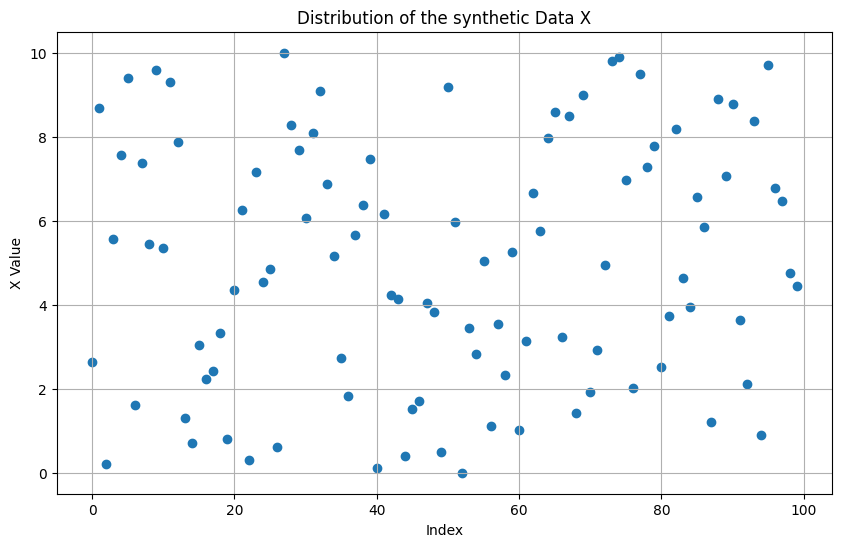

In [14]:
# Plot the Distribution of the synthetic data X
plt.figure(figsize=(10, 6))
plt.scatter(range(len(X)), X)
plt.title('Distribution of the synthetic Data X')
plt.xlabel('Index')
plt.ylabel('X Value')
plt.grid(True)
plt.show()

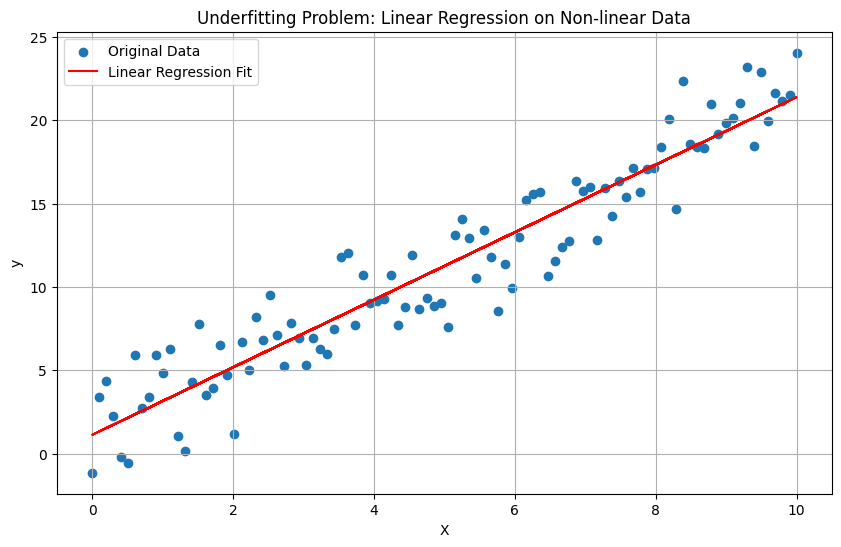

In [15]:
#Plot the Data with a Line of Linear Regression.
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Original Data')
plt.plot(X, y_pred, color='red', label='Linear Regression Fit')
plt.title('Underfitting Problem: Linear Regression on Non-linear Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

#### **Underfitting**

**Underfitting** ocorre quando um modelo de machine learning é **muito simples** para capturar os padrões e a complexidade dos dados de treinamento. É como tentar ajustar uma linha reta a dados que claramente seguem uma curva.

**Características do Underfitting:**

*   O modelo tem **baixo desempenho** tanto nos dados de treinamento quanto em dados novos (teste).
*   Não consegue capturar a relação subjacente nos dados.
*   Indica que o modelo precisa ser mais complexo ou que faltam features relevantes.

In [17]:
#Exemplo com Regressão Polynomial
degree = 15
poly_features = PolynomialFeatures(degree=degree, include_bias=False)

In [19]:
#Criando um novo Modelo com Regressão Polynomial
new_model = make_pipeline(poly_features, LinearRegression())
new_model.fit(X, y);

In [20]:
#Gerando a Predição.
y_pred = new_model.predict(X)

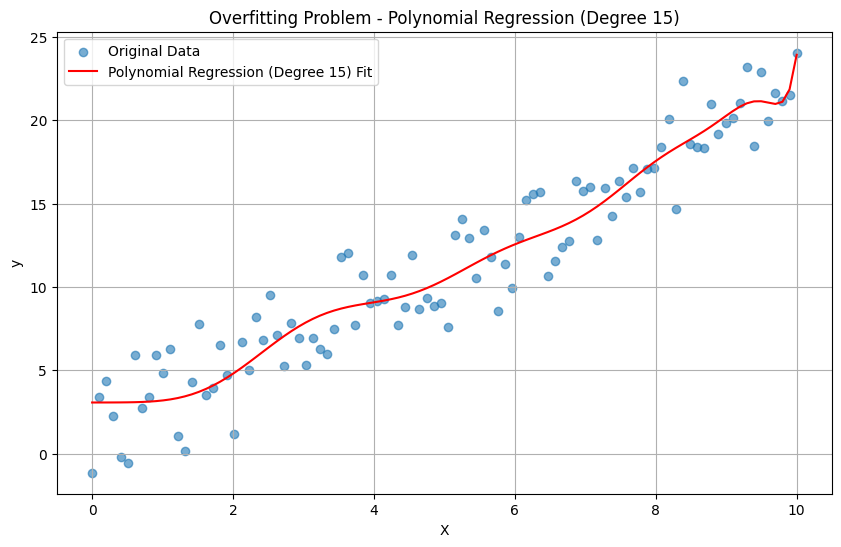

In [22]:
# Show the Results.
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Original Data', alpha=0.6)

# Sort X before plotting the curve to ensure a smooth line
X_sorted = np.sort(X, axis=0)
y_pred_overfitting_sorted = new_model.predict(X_sorted)

plt.plot(X_sorted, y_pred_overfitting_sorted, color='red', label=f'Polynomial Regression Fit')
plt.title(f'Overfitting Problem - Polynomial Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

#### **Overfitting**

**Overfitting** acontece quando o modelo é excessivamente complexo e se ajusta não apenas ao padrão dos dados de treinamento, mas também ao ruído aleatório e às variações específicas desses dados.

**Características do Overfitting:**

* **Modelo Complexo e Ajuste ao Ruído** O modelo não distingue entre o sinal real e o ruído nos dados de treinamento. Ele memoriza os pontos de treinamento, em vez de aprender a relação geral.

* **Má Generalização:** Embora o modelo tenha um desempenho quase perfeito nos dados de treinamento (a curva passa muito perto dos pontos), ele não capturará a verdadeira relação subjacente e terá um desempenho muito ruim em novos dados que não foram vistos durante o treinamento. A curva provavelmente se comportará de forma errática fora do intervalo dos dados de treinamento.

### Regressão Logística

A Regressão Logística é usada para problemas de **classificação**, geralmente binária (duas classes), embora possa ser estendida para multiclasse. Em vez de prever um valor contínuo, ela modela a **probabilidade** de uma instância pertencer a uma determinada classe.

A Regressão Logística utiliza a função sigmoide (ou função logística) para mapear a saída de uma combinação linear das features para um valor entre 0 e 1. A função sigmoide é definida como:

$\sigma(z) = \frac{1}{1 + e^{-z}}$

Onde $z$ é a combinação linear das features:

$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$

A probabilidade de uma instância pertencer à classe positiva (geralmente representada por 1) é dada por:

$P(y=1 | x_1, ..., x_n) = \sigma(\beta_0 + \beta_1 x_1 + ... + \beta_n x_n)$

A probabilidade de pertencer à classe negativa (geralmente representada por 0) é $P(y=0 | x_1, ..., x_n) = 1 - P(y=1 | x_1, ..., x_n)$.

Com base nessa probabilidade, uma instância é classificada na classe positiva se $P(y=1 | x_1, ..., x_n)$ for maior que um determinado limite (geralmente 0.5), e na classe negativa caso contrário. O algoritmo de Regressão Logística aprende os coeficientes $\beta_0, \beta_1, ..., \beta_n$ que maximizam a verossimilhança dos dados observados.

In [24]:
#Gerando novos Dados Sintéticos
np.random.seed(42)
X_log, y_log = make_blobs(n_samples=100, n_features=2, centers=2, random_state=42)

In [25]:
# Mostrando o Tamanho dos Dados Gerados
print("Shape of X_log:", X_log.shape)
print("Shape of y_log:", y_log.shape)

Shape of X_log: (100, 2)
Shape of y_log: (100,)


In [28]:
#Criando um modelo de Regressão Logistica e Ajustando-o aos Dados
model_log = LogisticRegression()
model_log.fit(X_log, y_log);

In [30]:
#Ajuste dos Dados ( Previsores ) + Ajuste da Forma Dataframe
x_min, x_max = X_log[:, 0].min() - 1, X_log[:, 0].max() + 1
y_min, y_max = X_log[:, 1].min() - 1, X_log[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

Z = model_log.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

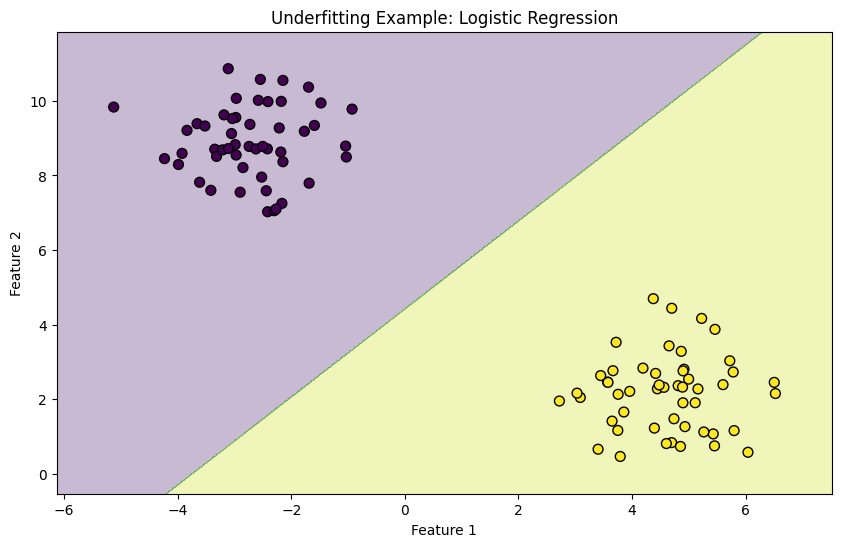

In [31]:
#Show the Results
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_log[:, 0], X_log[:, 1], c=y_log, edgecolors='k', marker='o', s=50)

plt.title('Underfitting Example: Logistic Regression')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

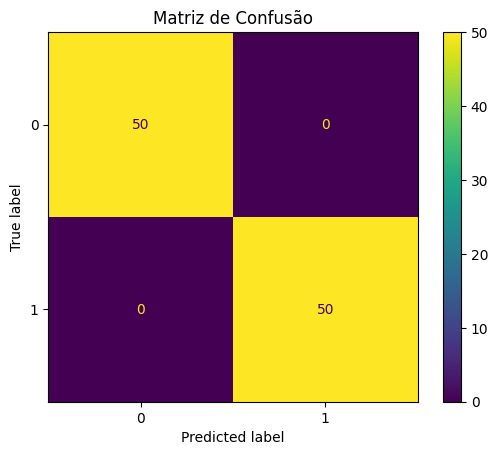

In [34]:
#Exemplo de Matriz de Confusão
y_pred_log = model_log.predict(X_log)
cm = confusion_matrix(y_log, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_log.classes_)
disp.plot()
plt.title('Matriz de Confusão')
plt.show()

In [36]:
#Exemplo de Overfitting com a Regressão Logistica
degree = 10
poly_features = PolynomialFeatures(degree=degree, include_bias=False)
new_model_log = make_pipeline(poly_features, LogisticRegression(C=1000, solver='liblinear', random_state=42))
new_model_log.fit(X_log, y_log);

In [37]:
#Ajuste dos Dados ( Previsores ) + Ajuste da Forma Dataframe
x_min, x_max = X_log[:, 0].min() - 1, X_log[:, 0].max() + 1
y_min, y_max = X_log[:, 1].min() - 1, X_log[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predict the class for each point in the meshgrid
Z = new_model_log.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

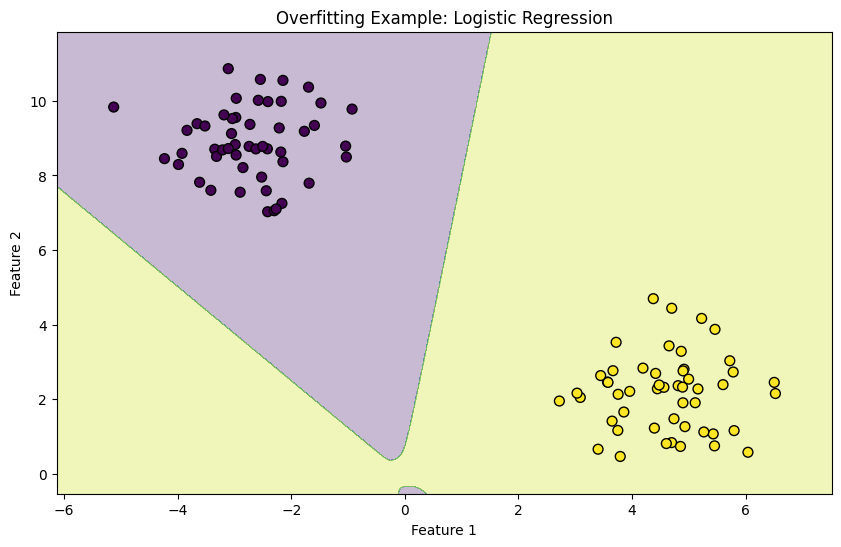

In [39]:
#Show the Results
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_log[:, 0], X_log[:, 1], c=y_log, edgecolors='k', marker='o', s=50)

plt.title(f'Overfitting Example: Logistic Regression')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()